# a) Planeje um experimento no delineamento inteiramente casualizado com um fator quantitativo.

Objetivo: Determinar a dose de nitrogênio (N) que maximiza a produtividade da cultura do milho.

Delineamento: Inteiramente Casualizado (DIC).

Fator Quantitativo: Doses de Nitrogênio (kg/ha).

Níveis (Tratamentos): 5 níveis: 0, 50, 100, 150, 200 kg/ha.

Variável Resposta: Produtividade de grãos (kg/ha).

Repetições: 4 repetições por tratamento.

# b) Para um conjunto de dados obtido de um experimento instalado no delineamento inteiramente casualizado com um fator quantitativo, faça a análise dos dados e interprete os resultados.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt

# --- 1. Criação de um Conjunto de Dados Hipotético ---
dados = {
    'dose_N': np.repeat([0, 50, 100, 150, 200], 4), # 5 doses, 4 repetições
    'produtividade': [
        3100, 3200, 3050, 3150,  # Dose 0
        5500, 5650, 5450, 5600,  # Dose 50
        7800, 7950, 7750, 7900,  # Dose 100
        8600, 8500, 8700, 8550,  # Dose 150
        8450, 8300, 8350, 8400   # Dose 200 
    ]
}
df = pd.DataFrame(dados)
print("--- Tabela de Dados do Experimento ---")
print(df)
print("\n" * 2)

--- Tabela de Dados do Experimento ---
    dose_N  produtividade
0        0           3100
1        0           3200
2        0           3050
3        0           3150
4       50           5500
5       50           5650
6       50           5450
7       50           5600
8      100           7800
9      100           7950
10     100           7750
11     100           7900
12     150           8600
13     150           8500
14     150           8700
15     150           8550
16     200           8450
17     200           8300
18     200           8350
19     200           8400





In [10]:
# --- 2. Análise de Variância (ANOVA) ---
# Primeiro, verificamos se as doses, como um todo, têm um efeito significativo.

modelo_anova = ols('produtividade ~ C(dose_N)', data=df).fit()
tabela_anova = sm.stats.anova_lm(modelo_anova, typ=2)

print("--- Tabela da Análise de Variância (ANOVA) ---")
print(tabela_anova)
print("\n" * 2)



--- Tabela da Análise de Variância (ANOVA) ---
               sum_sq    df            F        PR(>F)
C(dose_N)  87175500.0   4.0  3374.535484  5.874965e-22
Residual      96875.0  15.0          NaN           NaN





In [11]:
# --- 3. Análise de Regressão ---
# Como a ANOVA foi significativa, vamos ajustar modelos de regressão para descrever a relação.
# Vamos testar um modelo linear e um quadrático.

# Modelo de Regressão Linear: y = b0 + b1*x
modelo_linear = ols('produtividade ~ dose_N', data=df).fit()

# Modelo de Regressão Quadrático: y = b0 + b1*x + b2*x^2
# I(dose_N**2) informa ao statsmodels para tratar isso como uma variável calculada.
modelo_quadratico = ols('produtividade ~ dose_N + I(dose_N**2)', data=df).fit()

In [ ]:
print("--- Resumo do Modelo de Regressão Linear ---")
print(modelo_linear.summary())
print("\n" * 2)

--- Resumo do Modelo de Regressão Linear ---
                            OLS Regression Results                            
Dep. Variable:          produtividade   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     94.47
Date:                Mon, 21 Jul 2025   Prob (F-statistic):           1.38e-08
Time:                        21:59:04   Log-Likelihood:                -162.94
No. Observations:                  20   AIC:                             329.9
Df Residuals:                      18   BIC:                             331.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Interce

In [9]:
print("--- Resumo do Modelo de Regressão Quadrático ---")
print(modelo_quadratico.summary())
print("\n" * 2)

--- Resumo do Modelo de Regressão Quadrático ---
                            OLS Regression Results                            
Dep. Variable:          produtividade   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     1209.
Date:                Mon, 21 Jul 2025   Prob (F-statistic):           4.71e-19
Time:                        22:00:00   Log-Likelihood:                -131.62
No. Observations:                  20   AIC:                             269.2
Df Residuals:                      17   BIC:                             272.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [13]:
# --- 4. Cálculo da Dose de Máxima Eficiência Técnica (DMET) ---
# A partir do modelo quadrático: y = b0 + b1*x + b2*x^2
# A dose ótima (ponto de máximo da parábola) é calculada por: x = -b1 / (2*b2)

# Pegar os coeficientes do resumo do modelo quadrático
coefs = modelo_quadratico.params
b1 = coefs['dose_N']
b2 = coefs['I(dose_N ** 2)']

dose_otima = -b1 / (2 * b2)

# Calcular a produtividade máxima esperada nessa dose

In [8]:
produtividade_maxima = modelo_quadratico.predict(pd.DataFrame({'dose_N': [dose_otima]}))

print("--- Cálculo da Dose Ótima ---")
print(f"Coeficiente b1 (linear): {b1:.4f}")
print(f"Coeficiente b2 (quadrático): {b2:.4f}")
print(f"Dose de Máxima Eficiência (DMET): {dose_otima:.2f} kg/ha de N")
print(f"Produtividade Máxima Estimada: {produtividade_maxima.iloc[0]:.2f} kg/ha")
print("\n" * 2)


--- Cálculo da Dose Ótima ---
Coeficiente b1 (linear): 66.1464
Coeficiente b2 (quadrático): -0.1954
Dose de Máxima Eficiência (DMET): 169.30 kg/ha de N
Produtividade Máxima Estimada: 8612.38 kg/ha





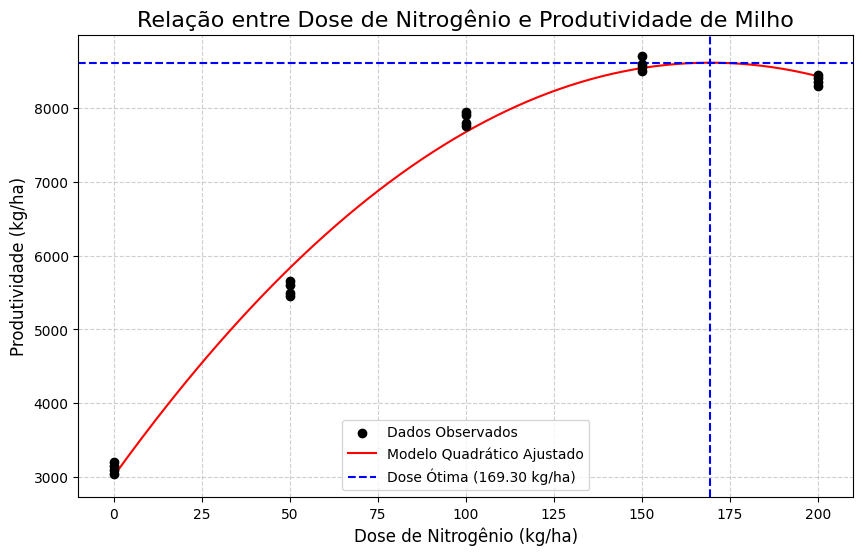

In [ ]:
# --- 5. Visualização Gráfica dos Resultados ---
plt.figure(figsize=(10, 6))

# Pontos dos dados originais
plt.scatter(df['dose_N'], df['produtividade'], label='Dados Observados', color='black', zorder=5)

# Linha da regressão quadrática
doses_plot = np.linspace(0, 200, 200)
prod_predita = modelo_quadratico.predict(pd.DataFrame({'dose_N': doses_plot}))
plt.plot(doses_plot, prod_predita, color='red', label='Modelo Quadrático Ajustado')

# Ponto de máximo
plt.axvline(x=dose_otima, color='blue', linestyle='--', label=f'Dose Ótima ({dose_otima:.2f} kg/ha)')
plt.axhline(y=produtividade_maxima.iloc[0], color='blue', linestyle='--')

# Configurações do gráfico
plt.title('Relação entre Dose de Nitrogênio e Produtividade de Milho', fontsize=16)
plt.xlabel('Dose de Nitrogênio (kg/ha)', fontsize=12)
plt.ylabel('Produtividade (kg/ha)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Por meio da análise de regressão podemos concluir que a relação não é uma linha reta, os ganhos de produtividade diminuem à medida que a dose de N aumenta, até que a curva atinge um pico. Isso significa que, a partir de um certo ponto, cada quilo a mais de fertilizante resulta em um acréscimo cada vez menor na produção. Ou seja, para maximizar a colheita de milho nas condições deste estudo, a recomendação técnica seria aplicar 169,30 kg de nitrogênio por hectare. Qualquer quantidade acima disso é ineficiente e economicamente desvantajosa.